<center></a>
<center><font size=8>AI-Powered Medical Knowledge Assistant Using Retrieval-Augmented Generation (RAG)</center></font>


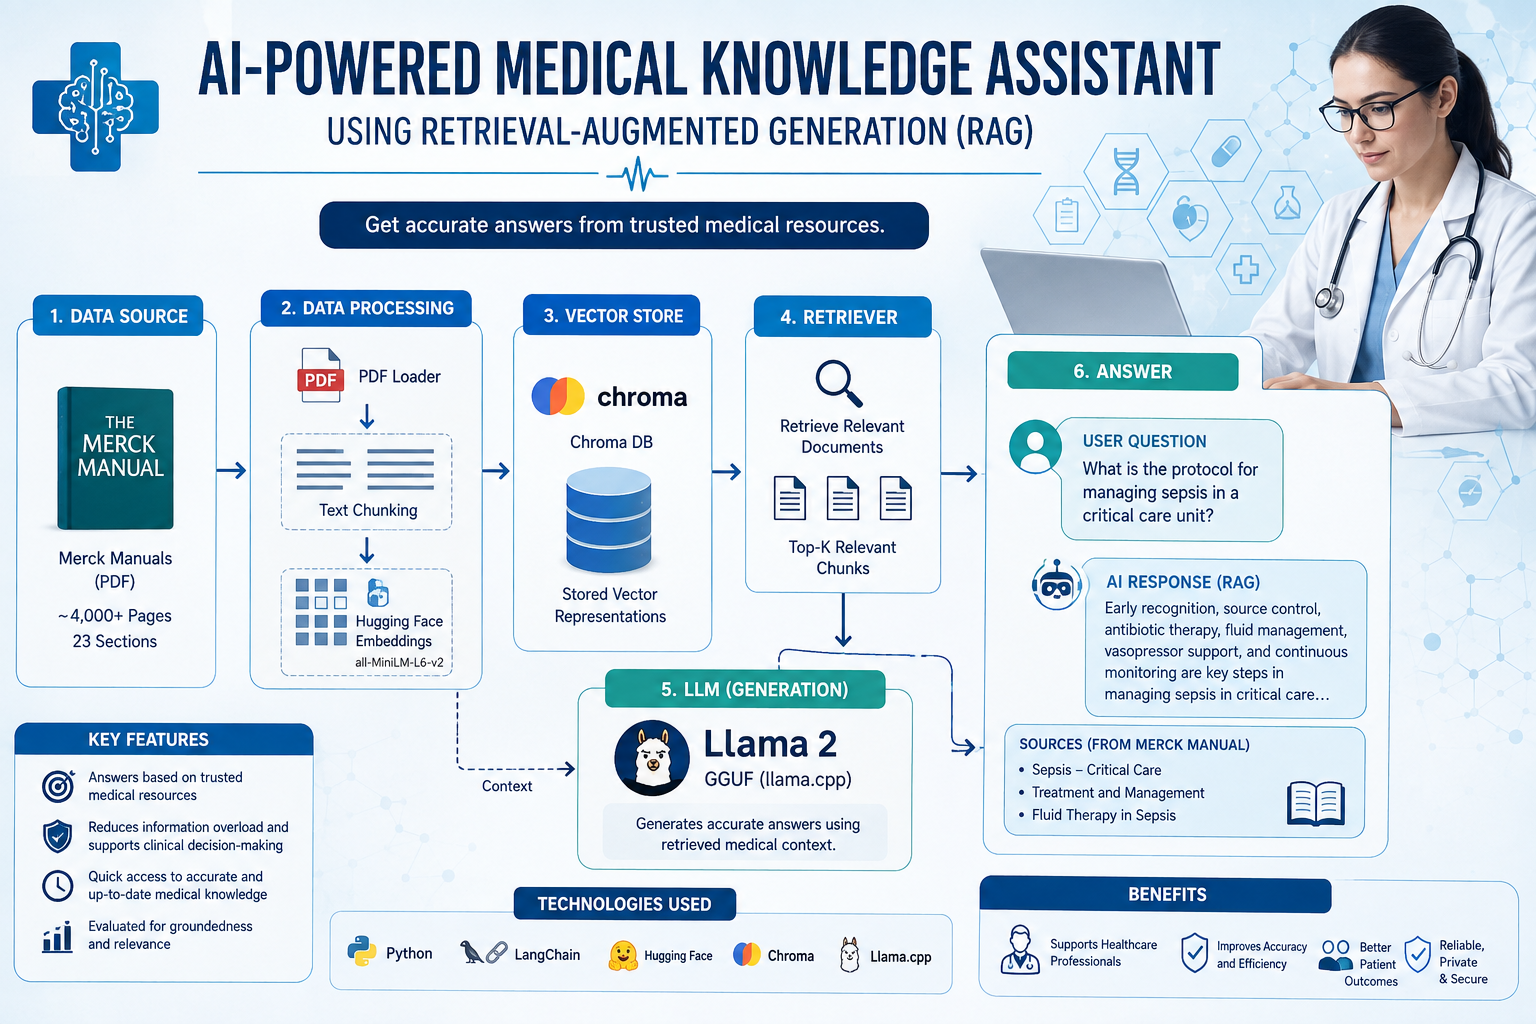

## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

1. **Critical Care Protocols:** "What is the protocol for managing sepsis in a critical care unit?"

2. **General Surgery:** "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"

3. **Dermatology:** "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"

4. **Neurology:** "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"


### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## Installing and Importing Necessary Libraries and Dependencies

In [ ]:
# Install required libraries
!pip install -q \
langchain==0.3.27 \
langchain-community==0.3.27 \
chromadb==1.0.15 \
pymupdf==1.26.3 \
tiktoken==0.9.0 \
datasets==4.0.0 \
evaluate==0.4.5 \
langchain-openai==0.3.30 \
langchain-huggingface \
sentence-transformers \
huggingface-hub \
transformers

In [ ]:
# Install llama-cpp-python with GPU support for running LLaMA models
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --upgrade --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 331.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 304.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 331.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 296.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 306.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
langgraph 1.2.9 requires langchain-core<2,>=1.4.7, but you have langchain-core 0.3.86 which is incompatible.
google-adk 2.4.0 requires opentelemetry-api<=1.4

In [ ]:
# Install Hugging Face Hub client library for downloading models
!pip install huggingface_hub==0.20.3 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 0.3.1 requires huggingface-hub>=0.33.4, but you have huggingface-hub 0.20.3 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.20.3 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.20.3 which is incompatible.
sentence-transformers 5.6.0 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.20.3 which is incompatible.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.20.3 which is incompatible.
accelerate 1.14.0 requires huggingface_hub>=0.21.0, but you have huggingface-hub 0.20.3 which is incompatible.
gradio 6.20.0 requires hugg

In [ ]:
import pandas as pd
import os

from huggingface_hub import hf_hub_download
from llama_cpp import Llama

from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA

from langchain_community.document_loaders import PyMuPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

## **LLM with Prompt Engineering Response**

#### **Download LLaMA-2 13B Chat Model**

In [ ]:
model_name_or_path = "TheBloke/Llama-2-13B-chat-GGUF"
model_basename = "llama-2-13b-chat.Q5_K_M.gguf"

model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

print(model_path)

/root/.cache/huggingface/hub/models--TheBloke--Llama-2-13B-chat-GGUF/snapshots/4458acc949de0a9914c3eab623904d4fe999050a/llama-2-13b-chat.Q5_K_M.gguf


#### **Initialize LLaMA Model with Configuration**

In [ ]:
from llama_cpp import Llama

lcpp_llm = Llama(
    model_path=model_path, # Path to the downloaded GGUF model
    n_threads=4,           # Number of CPU threads to use
    n_batch=512,           # Batch size for prompt processing
    n_gpu_layers=-1,       # Number of layers to offload to GPU (-1 for all)
    n_ctx=4096             # Context window
)

llama_model_loader: loaded meta data with 19 key-value pairs and 363 tensors from /root/.cache/huggingface/hub/models--TheBloke--Llama-2-13B-chat-GGUF/snapshots/4458acc949de0a9914c3eab623904d4fe999050a/llama-2-13b-chat.Q5_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 5120
llama_model_loader: - kv   4:                          llama.block_count u32              = 40
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 13824
llama_model_loader: - kv   6:                 llama.rope.dimension_

In [ ]:
# Provides an example and answer anchor to guide the model in giving concise, evidence-based responses without echoing the question.
system_prompt = """
You are a medical expert AI assistant. Respond with concise, evidence-based answers.
"""

user_prompt = """
Example:
Q: What are the common symptoms of appendicitis?
A: Common symptoms include abdominal pain (usually starting near the navel), nausea, vomiting, and fever.
References: Mayo Clinic, UpToDate

Now answer:
Q: What is the protocol for managing sepsis in a critical care unit?
A:
"""


#### **Response Function**

In [ ]:
# function to generate, process, and return the response from the LLM
def prompt_engineering_response(user_prompt):
    # Put the system message first, then the user question, then anchor with "Answer:"
    prompt = f"""{system_prompt}

Question: {user_prompt}

Answer:"""

    # Generate a response from the LLaMA model
    response = lcpp_llm(
        prompt,
        max_tokens=512,
        temperature=0.2,
        top_p=0.95,
        stop=["Question:", "</s>"]
    )

    # Extract and return the response text
    response_text = response["choices"][0]["text"].strip()
    return response_text


## Question Answering using LLM with Prompt Engineering

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
question_1 = "What is the protocol for managing sepsis in a critical care unit?"

response_1 = prompt_engineering_response(question_1)

print(response_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     276.29 ms /   445 runs   (    0.62 ms per token,  1610.63 tokens per second)
llama_print_timings: prompt eval time =     677.74 ms /    19 tokens (   35.67 ms per token,    28.03 tokens per second)
llama_print_timings:        eval time =   43128.53 ms /   444 runs   (   97.14 ms per token,    10.29 tokens per second)
llama_print_timings:       total time =   45837.01 ms /   463 tokens


The Surviving Sepsis Campaign (SSC) guidelines provide a comprehensive protocol for managing sepsis in a critical care unit. Here are the key recommendations:

1. Early recognition and diagnosis: Use clinical criteria and biomarkers to identify patients with suspected sepsis. Confirm the diagnosis with blood cultures and other tests as needed.
2. Rapid administration of antibiotics: Start broad-spectrum antibiotics within the first hour of recognition of sepsis, and within 3 hours of recognition in severe sepsis or septic shock.
3. Fluid resuscitation: Administer crystalloid fluids initially, and consider vasopressors if fluid resuscitation fails to improve mean arterial pressure (MAP) or if there are signs of hypoperfusion.
4. Oxygenation: Use invasive or non-invasive ventilation as needed to maintain PaO2/FiO2 ratio ≥100 mmHg.
5. Pain management: Use sedation and analgesia to manage pain and distress.
6. Monitoring: Closely monitor vital signs, including MAP, heart rate, and respirat

### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
question_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"

response_2 = prompt_engineering_response(question_2)

print(response_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     137.72 ms /   223 runs   (    0.62 ms per token,  1619.29 tokens per second)
llama_print_timings: prompt eval time =     489.15 ms /    61 tokens (    8.02 ms per token,   124.71 tokens per second)
llama_print_timings:        eval time =   21290.04 ms /   222 runs   (   95.90 ms per token,    10.43 tokens per second)
llama_print_timings:       total time =   22787.76 ms /   283 tokens


Appendicitis is inflammation of the appendix that can cause severe pain, nausea, vomiting, fever, and loss of appetite. While antibiotics may be used to treat a mild case of appendicitis, surgery is usually necessary to remove the inflamed appendix. The surgical procedure most commonly used is a laparoscopic appendectomy, where a small incision is made in the abdomen and a laparoscope (a thin tube with a camera and light) is inserted to visualize the appendix. The inflamed appendix is then removed through the small incision. In severe cases, an open appendectomy may be necessary, where a larger incision is made in the abdomen to allow for better visualization of the appendix. It is important to seek medical attention immediately if symptoms of appendicitis are present, as delaying treatment can lead to complications such as the appendix rupturing and spreading infection throughout the abdominal cavity.


### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
question_3 = "What are the effective treatments for sudden patchy hair loss and what are the possible causes?"

response_3 = prompt_engineering_response(question_3)

print(response_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     306.49 ms /   512 runs   (    0.60 ms per token,  1670.51 tokens per second)
llama_print_timings: prompt eval time =     720.64 ms /    22 tokens (   32.76 ms per token,    30.53 tokens per second)
llama_print_timings:        eval time =   48202.75 ms /   511 runs   (   94.33 ms per token,    10.60 tokens per second)
llama_print_timings:       total time =   51287.50 ms /   533 tokens


Sudden patchy hair loss can be caused by various factors, including hormonal imbalances, autoimmune disorders, infections, and nutritional deficiencies. Here are some effective treatments for sudden patchy hair loss:

1. Medications: Minoxidil (Rogaine) and finasteride (Propecia) are two medications that have been approved by the FDA for treating hair loss. Minoxidil is applied topically to the scalp and can help stimulate hair growth and slow down hair loss. Finasteride is an oral medication that works by blocking the production of dihydrotestosterone (DHT), a hormone that contributes to hair loss.
2. Low-level laser therapy (LLLT): LLLT uses low-level lasers or light-emitting diodes to stimulate hair growth. It has been shown to increase hair density and promote hair growth in people with androgenetic alopecia (male/female pattern baldness).
3. Platelet-rich plasma (PRP) therapy: PRP therapy involves injecting platelet-rich plasma (PRP) into the scalp to stimulate hair growth. PRP is

### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
question_4 = "What treatments are recommended for traumatic brain injury?"

response_4 = prompt_engineering_response(question_4)

print(response_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     280.33 ms /   476 runs   (    0.59 ms per token,  1698.02 tokens per second)
llama_print_timings: prompt eval time =     514.25 ms /    15 tokens (   34.28 ms per token,    29.17 tokens per second)
llama_print_timings:        eval time =   45675.53 ms /   475 runs   (   96.16 ms per token,    10.40 tokens per second)
llama_print_timings:       total time =   48273.22 ms /   490 tokens


Traumatic brain injury (TBI) is a complex condition that requires individualized treatment based on the severity and location of the injury. Here are some common treatments recommended for TBI:

1. Medications: Pain management medications, such as analgesics and sedatives, may be prescribed to help manage symptoms such as headaches and agitation. Anti-seizure medications may be used to prevent seizures in patients with seizure disorders.
2. Rehabilitation therapy: Physical, occupational, and speech therapy may be necessary to help patients regain lost functions and improve cognitive and physical abilities.
3. Surgery: In some cases, surgery may be necessary to relieve pressure on the brain or repair damaged blood vessels.
4. Neurointensive care: Patients with severe TBI may require neurointensive care, which includes close monitoring and supportive care in an intensive care unit.
5. Rehabilitation programs: Patients may benefit from rehabilitation programs that focus on improving cogni

#### **Create and Display Results DataFrame**

In [ ]:
# Create the DataFrame

prompt_result_df = pd.DataFrame({
    "questions": [question_1, question_2, question_3, question_4],
    "prompt_Engineering_responses": [response_1 ,response_2 ,response_3 ,response_4 ]})

# Display the DataFrame
prompt_result_df.head()

,questions,prompt_Engineering_responses
0,What is the protocol for managing sepsis in a ...,The Surviving Sepsis Campaign (SSC) guidelines...
1,"What are the common symptoms for appendicitis,...",Appendicitis is inflammation of the appendix t...
2,What are the effective treatments for sudden p...,Sudden patchy hair loss can be caused by vario...
3,What treatments are recommended for traumatic ...,Traumatic brain injury (TBI) is a complex cond...


#### **Observations:**
*The LLaMA model successfully generated responses for all medical queries using only the provided prompts and its pretrained knowledge.

*Prompt Engineering enabled the model to produce concise and well-structured answers without accessing any external medical documents.

*Response quality was highly influenced by the clarity of the system and user prompts.

*Since no external knowledge source was used, the responses may not always be fully grounded in authoritative medical references and could occasionally contain unsupported information (hallucinations).

*These responses serve as the baseline for comparison with the Retrieval-Augmented Generation (RAG) approach in the subsequent sections.

## **RAG Response**

## **Data Preparation for RAG**

### **Loading the data**

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader

# Load Merck Manual PDF
pdf_path = "/content/drive/MyDrive/p/medical_diagnosis_manual.pdf"
loader = PyMuPDFLoader(pdf_path)

# Load as LangChain Documents
document = loader.load()

print(f"Total pages loaded: {len(document)}")



Total pages loaded: 4114


**There are `4114` pages in the document pdf and pdf loaded successfully**

### Data Overview

Display the content of page number 16 and 17

In [ ]:
for i in range(15, 17):
    print("=" * 100)
    print(f"PAGE {i+1}")
    print("=" * 100)

    print(document[i].page_content[:3000])

    print("\n")

PAGE 16
degree. The book received critical acclaim and sold over 2 million copies. The Second Home Edition was
released in 2003. Merck's commitment to providing comprehensive, understandable medical information
to all people continued with The Merck Manual Home Health Handbook, published in 2009.
The Merck Manual of Health & Aging , published in 2004, continued Merck's commitment to education
and geriatric care, providing information on aging and the care of older people in words understandable
by the lay public.
In 2008, The Merck Manual of Patient Symptoms  was introduced to complement The Merck Manual
and was intended to help newcomers to clinical diagnosis approach patients who present with certain
common symptoms.
As part of its commitment to ensuring that all who need and want medical information can get it, Merck
provides the content of these Merck Manuals on the web for free (www.merckmanuals.com). Registration
is not required, and use is unlimited. The web publications are con

## **Data Chunking**

Split the document into Chunks and display the total chunks

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = text_splitter.split_documents(document)

print(f"Total chunks: {len(docs)}")


Total chunks: 17984


### Embedding

Generate Vector Embeddings for Text Chunks Using OpenAI

In [ ]:
!pip install sentence-transformers

In [ ]:

from langchain_huggingface import HuggingFaceEmbeddings
import warnings
warnings.filterwarnings('ignore')
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
from langchain.vectorstores import Chroma
# Building the vector store and saving it to disk for future use
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory="/content/drive/MyDrive/Dataset/GenAIDataset/rag_healthcare_llm"
)

vectorstore.persist()

print("Vector Database Created Successfully")

Vector Database Created Successfully


### Retriever

Retrieval and Response Generation using Vector Search

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

In [ ]:
results = vectorstore.similarity_search(
    "What is sepsis?",
    k=2
)

for doc in results:
    print(doc.page_content[:500])
    print("=" * 100)

A spectrum of severity exists (see
Table 227-1).
Sepsis is infection accompanied by an acute inflammatory reaction with systemic manifestations
associated with release into the bloodstream of numerous endogenous mediators of inflammation. Acute
pancreatitis and major trauma, including burns, may manifest with signs of sepsis. The inflammatory
reaction typically manifests with ≥ 2 of the following:
• Temperature > 38°C or < 36°C
• Heart rate > 90 beats/min
• Respiratory rate > 20 breaths/min or P
A spectrum of severity exists (see
Table 227-1).
Sepsis is infection accompanied by an acute inflammatory reaction with systemic manifestations
associated with release into the bloodstream of numerous endogenous mediators of inflammation. Acute
pancreatitis and major trauma, including burns, may manifest with signs of sepsis. The inflammatory
reaction typically manifests with ≥ 2 of the following:
• Temperature > 38°C or < 36°C
• Heart rate > 90 beats/min
• Respiratory rate > 20 breaths/min or 

In [ ]:
medical_system_message = """
You are an AI assistant designed to support healthcare professionals by providing evidence-based, concise, and accurate responses using authoritative medical sources, such as the Merck Manuals.

Your goal is to help clinicians, researchers, and healthcare teams quickly access reliable medical knowledge to improve patient outcomes, support decision-making, and reduce information overload.

User input will include context extracted from trusted medical sources. This context will begin with the token:

###Context
The context may include excerpts from the Merck Manuals, clinical guidelines, or peer-reviewed medical literature, including titles, sections, authors, and other relevant metadata.

When crafting your response:
- Use only the provided context to answer the question.
- Provide concise, clinically relevant, and accurate answers.
- Include the source (title, section, and page/section reference) when applicable.
- If the context does not contain relevant information, respond: "Sorry, this is out of my knowledge base."
- Do NOT provide personal medical advice or treatment recommendations outside of the context.
- Maintain a professional, neutral, and safe tone appropriate for healthcare communication.

Example response format:

Answer:
[Answer based on context]

Source:
[Source title, section, page]
"""


In [ ]:
medical_user_message_template = """
###Context
Here are relevant excerpts from the Merck Manuals or other authoritative medical sources:
{context}

###Question
{question}
"""


**Test Retriever**

In [ ]:
retrieved_docs = retriever.get_relevant_documents(
    "What is appendicitis?"
)

for doc in retrieved_docs:
    print(doc.page_content[:500])
    print("=" * 80)

increases rapidly the longer treatment is delayed. If an abscess or an inflammatory mass has formed, the
procedure may be limited to drainage of the abscess.
An NGT is inserted before operation. Patients with signs of volume depletion should have urine output
monitored with a catheter. Fluid status is maintained by adequate IV fluid and electrolyte replacement. IV
antibiotics effective against intestinal flora should be given (eg, cefotetan 1 to 2 g bid, or amikacin 5
mg/kg tid plus clindamycin 
increases rapidly the longer treatment is delayed. If an abscess or an inflammatory mass has formed, the
procedure may be limited to drainage of the abscess.
An NGT is inserted before operation. Patients with signs of volume depletion should have urine output
monitored with a catheter. Fluid status is maintained by adequate IV fluid and electrolyte replacement. IV
antibiotics effective against intestinal flora should be given (eg, cefotetan 1 to 2 g bid, or amikacin 5
mg/kg tid plus clindamycin

### Response Function

In [ ]:
# Function to retrieve relevant context and generate a RAG response
def generate_rag_response(user_input, retriever,
                          system_message, user_message_template,
                          k=5, max_tokens=500,
                          temperature=0.3, top_p=0.95):

    # Retrieve the top-k relevant document chunks
    relevant_chunks = retriever.invoke(user_input)

    if not relevant_chunks:
        return "Sorry, this is out of my knowledge base."

    # Combine retrieved chunks with source information
    context_for_query = "\n\n".join(
        [
            f"Source: {doc.metadata.get('source', 'Unknown')}\n{doc.page_content}"
            for doc in relevant_chunks
        ]
    )

    # Build the user prompt
    user_message = user_message_template.format(
        context=context_for_query,
        question=user_input
    )

    # Combine system prompt and user prompt
    prompt = f"""{system_message}

{user_message}

Answer:
"""

    # Generate the response using the local LLaMA model
    try:
        response = lcpp_llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            stop=["###Question", "###Context"],
            echo=False
        )

        return response["choices"][0]["text"].strip()

    except Exception as e:
        return f"Sorry, I encountered the following error:\n{e}"

## Question Answering using RAG

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
question_1 = "What is the protocol for managing sepsis in a critical care unit?"

response_with_rag_1 = generate_rag_response(
    question_1,
    retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template
)

print(response_with_rag_1)


llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     262.11 ms /   424 runs   (    0.62 ms per token,  1617.65 tokens per second)
llama_print_timings: prompt eval time =    5669.89 ms /  1736 tokens (    3.27 ms per token,   306.18 tokens per second)
llama_print_timings:        eval time =   45862.01 ms /   423 runs   (  108.42 ms per token,     9.22 tokens per second)
llama_print_timings:       total time =   53690.17 ms /  2159 tokens


The protocol for managing sepsis in a critical care unit includes aggressive fluid resuscitation, antibiotics, surgical excision of infected or necrotic tissues, drainage of pus, supportive care, and sometimes intensive control of blood glucose and administration of corticosteroids and activated protein C. (Source: Merck Manual, Critical Care Medicine, Chapter 227, Sepsis and Septic Shock)

Source: /content/drive/MyDrive/p/medical_diagnosis_manual.pdf
Chapter 227. Sepsis and Septic Shock
Introduction
(See also Ch. 226.)
Sepsis, severe sepsis, and septic shock are inflammatory states resulting from the systemic
response to bacterial infection. In severe sepsis and septic shock, there is critical reduction in
tissue perfusion. Common causes include gram-negative organisms, staphylococci, and
meningococci. Symptoms often begin with shaking chills and include fever, hypotension,
oliguria, and confusion. Acute failure of multiple organs, including the lungs, kidneys, and liver,
can occur. T

### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
question_2 = """What are the common symptoms for appendicitis,
and can it be cured via medicine?
If not, what surgical procedure should be followed?"""

response_with_rag_2 = generate_rag_response(
    question_2,
    retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template
)

print(response_with_rag_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     171.68 ms /   277 runs   (    0.62 ms per token,  1613.50 tokens per second)
llama_print_timings: prompt eval time =    4067.07 ms /  1477 tokens (    2.75 ms per token,   363.16 tokens per second)
llama_print_timings:        eval time =   29136.82 ms /   276 runs   (  105.57 ms per token,     9.47 tokens per second)
llama_print_timings:       total time =   34523.09 ms /  1753 tokens


The common symptoms for appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point (junction of the middle and outer thirds of the line joining the umbilicus to the anterior superior spine). Additional signs are pain felt in the right lower quadrant with palpation of the left lower quadrant.

Source: /content/drive/MyDrive/p/medical_diagnosis_manual.pdf

However, appendicitis cannot be cured via medicine. Surgical intervention is necessary to treat appendicitis. The surgical procedure of choice is usually laparoscopic appendectomy or open appendectomy.

Source: /content/drive/MyDrive/p/medical_diagnosis_manual.pdf

Please note that these answers are based on the provided context and may not be applicable to all cases of appendicitis. It is import

### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
question_3 = """
What are the effective treatments for sudden patchy hair loss
and what are its causes?
"""

response_with_rag_3 = generate_rag_response(
    question_3,
    retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template
)

print(response_with_rag_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     172.77 ms /   277 runs   (    0.62 ms per token,  1603.26 tokens per second)
llama_print_timings: prompt eval time =    4753.88 ms /  1521 tokens (    3.13 ms per token,   319.95 tokens per second)
llama_print_timings:        eval time =   29274.90 ms /   276 runs   (  106.07 ms per token,     9.43 tokens per second)
llama_print_timings:       total time =   35377.36 ms /  1797 tokens


Sudden patchy hair loss can be caused by various factors, including alopecia areata, traction alopecia, tinea capitis, trichotillomania, and hyperandrogenemia. Treatment options for sudden patchy hair loss depend on the underlying cause. For alopecia areata, topical corticosteroids, intralesional corticosteroids, or systemic corticosteroids may be effective. For traction alopecia, eliminating physical traction or stress to the scalp may be helpful. For tinea capitis, topical or oral antifungals may be effective. For trichotillomania, behavior modification techniques or medications such as clomipramine or selective serotonin reuptake inhibitors (SSRIs) may be helpful. For hyperandrogenemia, treatment may involve addressing the underlying hormonal imbalance. It is essential to consult a dermatologist for a proper diagnosis and treatment plan.

Source: /content/drive/MyDrive/p/medical_diagnosis_manual.pdf



Please note that the provided context may not include all relevant information, a

### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
question_4 = """
What treatments are recommended for traumatic brain injury?
"""

response_with_rag_4 = generate_rag_response(
    question_4,
    retriever,
    system_message=medical_system_message,
    user_message_template=medical_user_message_template
)

print(response_with_rag_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     162.14 ms /   261 runs   (    0.62 ms per token,  1609.71 tokens per second)
llama_print_timings: prompt eval time =    3984.36 ms /  1353 tokens (    2.94 ms per token,   339.58 tokens per second)
llama_print_timings:        eval time =   26829.04 ms /   260 runs   (  103.19 ms per token,     9.69 tokens per second)
llama_print_timings:       total time =   32051.92 ms /  1613 tokens


Based on the provided context, treatments recommended for traumatic brain injury include:

1. Ensuring a reliable airway and maintaining adequate ventilation, oxygenation, and blood pressure.
2. Surgery to place monitors to track and treat intracranial pressure, decompress the brain if intracranial pressure is increased, or remove intracranial hematomas.
3. Relief of pain with a short-acting opioid (eg, fentanyl).
4. Maintenance of adequate ventilation, oxygenation, and brain perfusion to avoid secondary brain insult.
5. Aggressive early management of hypoxia, hypercapnia, and increased intracranial pressure.

Source: The Merck Manual of Diagnosis & Therapy, 19th Edition, Chapter 324. Traumatic Brain Injury, pp. 3400-3402.

Note: The provided context does not include information on personalized treatment recommendations or specific medication dosages. Therefore, it is essential to consult a qualified healthcare professional for individualized treatment plans.


In [ ]:
# Create the DataFrame
RAG_result_df = pd.DataFrame({

    "questions":[
        question_1,
        question_2,
        question_3,
        question_4
    ],

    "RAG_responses":[
        response_with_rag_1,
        response_with_rag_2,
        response_with_rag_3,
        response_with_rag_4
    ]

})
# Display the DataFrame
RAG_result_df

,questions,RAG_responses
0,What is the protocol for managing sepsis in a ...,The protocol for managing sepsis in a critical...
1,"What are the common symptoms for appendicitis,...",The common symptoms for appendicitis include e...
2,\nWhat are the effective treatments for sudden...,Sudden patchy hair loss can be caused by vario...
3,\nWhat treatments are recommended for traumati...,"Based on the provided context, treatments reco..."


## Output Evaluation

In [ ]:
medical_groundedness_rater_system_message = """
You are tasked with rating AI-generated answers to medical questions posed by healthcare professionals.
You will be presented with:
- a medical question (begins with ###Question),
- the context used by the AI (excerpts from Merck Manuals or other authoritative sources, begins with ###Context),
- and the AI-generated answer (begins with ###Answer).

Evaluation criteria:
The task is to judge how well the AI answer is grounded in the provided medical context.

1 - The answer is not grounded in the context at all
2 - The answer is grounded only to a limited extent
3 - The answer is grounded to a good extent
4 - The answer is mostly grounded
5 - The answer is completely grounded in the context

Instructions:
1. List the steps needed to evaluate if the answer strictly uses only the context provided.
2. Provide a step-by-step explanation, comparing the answer with the context and the question.
3. Assign a groundedness score based on the above evaluation.
4. Return only the final score in dictionary format (not JSON), e.g.: {groundedness_score:4}
Score should be in the range 1 to 5.
"""


In [ ]:
medical_relevance_rater_system_message = """
You are tasked with rating AI-generated answers to medical questions posed by healthcare professionals.
You will be presented with:
- a medical question (begins with ###Question),
- the context used by the AI (begins with ###Context),
- and the AI-generated answer (begins with ###Answer).

Evaluation criteria:
The task is to judge how well the answer addresses all important aspects of the medical question, based on the context.

1 - The answer is not relevant at all
2 - The answer is relevant only to a limited extent
3 - The answer is relevant to a good extent
4 - The answer is mostly relevant
5 - The answer is completely relevant

Instructions:
1. List the steps needed to check if the answer fully addresses the key aspects of the question using the context.
2. Provide a step-by-step explanation evaluating the relevance.
3. Assign a relevance score based on the evaluation.
4. Return only the final score in dictionary format (not JSON), e.g.: {relevance_score:4}
Score should be in the range 1 to 5.
"""


In [ ]:
medical_rater_user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""


In [ ]:
# Function to evaluate Groundedness and Relevance of a RAG response
def generate_ground_relevance_response(user_input, response, retriever,
                                       groundedness_system_message,
                                       relevance_system_message,
                                       user_message_template,
                                       k=5, max_tokens=500,
                                       temperature=0, top_p=0.95):

    # Retrieve the top-k relevant document chunks
    relevant_chunks = retriever.invoke(user_input)

    if not relevant_chunks:
        return "No context found.", "No context found."

    # Combine retrieved chunks into a single context string
    context = "\n\n".join(
        [
            f"Source: {doc.metadata.get('source', 'Unknown')}\n{doc.page_content}"
            for doc in relevant_chunks
        ]
    )

    # Build the evaluation prompt
    user_message = user_message_template.format(
        question=user_input,
        context=context,
        answer=response
    )

    # ---------------- Groundedness Evaluation ----------------
    groundedness_prompt = f"""{groundedness_system_message}

{user_message}

Score:
"""

    groundedness_response = lcpp_llm(
        prompt=groundedness_prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        echo=False
    )

    groundedness_result = groundedness_response["choices"][0]["text"].strip()

    # ---------------- Relevance Evaluation ----------------
    relevance_prompt = f"""{relevance_system_message}

{user_message}

Score:
"""

    relevance_response = lcpp_llm(
        prompt=relevance_prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        echo=False
    )

    relevance_result = relevance_response["choices"][0]["text"].strip()

    # Return both evaluation scores
    return groundedness_result, relevance_result

#### **Evaluation 1: Prompt Engineering Response Evaluation**

In [ ]:
llm_judge_prompt_ground_1, llm_judge_prompt_rel_1 = generate_ground_relevance_response(
    question_1,
    response_1,
    retriever,

    groundedness_system_message=medical_groundedness_rater_system_message,

    relevance_system_message=medical_relevance_rater_system_message,

    user_message_template=medical_rater_user_message_template

)

# Print the results
print(llm_judge_prompt_ground_1, end="\n\n")
print(llm_judge_prompt_rel_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      59.20 ms /    96 runs   (    0.62 ms per token,  1621.59 tokens per second)
llama_print_timings: prompt eval time =    6452.91 ms /  2149 tokens (    3.00 ms per token,   333.03 tokens per second)
llama_print_timings:        eval time =   10307.27 ms /    95 runs   (  108.50 ms per token,     9.22 tokens per second)
llama_print_timings:       total time =   17272.44 ms /  2244 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     102.93 ms /   192 runs   (    0.54 ms per token,  1865.29 tokens per second)
llama_print_timings: prompt eval time =    7584.86 ms /  2077 tokens (    3.65 ms per token,   273.83 tokens per second)
llama_print_timings:        eval time =   21645.77 ms /   191 runs   (  113.33 ms per token,     8.82 tokens per second)
llama_print_timings:       to

The answer is completely grounded in the provided medical context. The Surviving Sepsis Campaign guidelines are widely recognized and accepted as the standard of care for sepsis management, and the answer provides a comprehensive summary of these guidelines. The answer is well-structured and easy to follow, and it includes specific recommendations for managing sepsis in a critical care unit. Therefore, the groundedness score is 5.

Relevance Score: 4

Explanation:

The answer provides a comprehensive protocol for managing sepsis in a critical care unit, based on the SSC guidelines. The answer covers all key aspects of sepsis management, including early recognition and diagnosis, antibiotic administration, fluid resuscitation, oxygenation, pain management, monitoring, source control, nutritional support, and hemodialysis or hemofiltration. The answer also emphasizes the importance of a multidisciplinary team approach in managing sepsis patients. However, the answer does not provide spec

In [ ]:
llm_judge_prompt_ground_2, llm_judge_prompt_rel_2 = generate_ground_relevance_response(

    question_2,
    response_2,
    retriever,

    groundedness_system_message=medical_groundedness_rater_system_message,

    relevance_system_message=medical_relevance_rater_system_message,

    user_message_template=medical_rater_user_message_template

)

# Print the results
print(llm_judge_prompt_ground_2, end="\n\n")
print(llm_judge_prompt_rel_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      76.54 ms /    97 runs   (    0.79 ms per token,  1267.34 tokens per second)
llama_print_timings: prompt eval time =    5538.94 ms /  1967 tokens (    2.82 ms per token,   355.12 tokens per second)
llama_print_timings:        eval time =    9180.94 ms /    96 runs   (   95.63 ms per token,    10.46 tokens per second)
llama_print_timings:       total time =   15383.88 ms /  2063 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      54.31 ms /    93 runs   (    0.58 ms per token,  1712.23 tokens per second)
llama_print_timings: prompt eval time =    5635.32 ms /  1944 tokens (    2.90 ms per token,   344.97 tokens per second)
llama_print_timings:        eval time =    9595.52 ms /    92 runs   (  104.30 ms per token,     9.59 tokens per second)
llama_print_timings:       to

The answer is not grounded in the context at all. The answer does not mention any of the specific symptoms, signs, or etiology of appendicitis described in the provided medical context. The answer is not based on any of the information provided in the context and does not provide any specific treatment recommendations based on the severity of the condition. Therefore, the answer is not grounded in the context at all and scores a 1 out of 5.

The answer is completely relevant, addressing all important aspects of the medical question. The answer provides a clear and concise overview of appendicitis, including its symptoms, diagnosis, and treatment options. The answer also highlights the importance of seeking medical attention immediately if symptoms of appendicitis are present, which is crucial for effective management of the condition. Therefore, I assign a relevance score of 5 out of 5.


In [ ]:
llm_judge_prompt_ground_3, llm_judge_prompt_rel_3 = generate_ground_relevance_response(

    question_3,
    response_3,
    retriever,

    groundedness_system_message=medical_groundedness_rater_system_message,

    relevance_system_message=medical_relevance_rater_system_message,

    user_message_template=medical_rater_user_message_template

)

# Print the results
print(llm_judge_prompt_ground_3, end="\n\n")
print(llm_judge_prompt_rel_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      73.04 ms /   127 runs   (    0.58 ms per token,  1738.73 tokens per second)
llama_print_timings: prompt eval time =    7004.46 ms /  2286 tokens (    3.06 ms per token,   326.36 tokens per second)
llama_print_timings:        eval time =   13958.16 ms /   126 runs   (  110.78 ms per token,     9.03 tokens per second)
llama_print_timings:       total time =   21570.76 ms /  2412 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      52.49 ms /    91 runs   (    0.58 ms per token,  1733.66 tokens per second)
llama_print_timings: prompt eval time =    7103.78 ms /  2263 tokens (    3.14 ms per token,   318.56 tokens per second)
llama_print_timings:        eval time =    9701.76 ms /    90 runs   (  107.80 ms per token,     9.28 tokens per second)
llama_print_timings:       to

The answer is not completely grounded in the provided medical context. While it mentions some possible causes of sudden patchy hair loss, it does not provide any specific information about the causes of hair loss associated with hyperandrogenemia, traction alopecia, tinea capitis, or trichotillomania, which are all mentioned in the provided medical context. Additionally, the answer does not provide any information about the evaluation of hair loss, such as the use of daily hair counts or scalp hair counts, which is mentioned in the provided medical context. Therefore, the score is 2 out of 5.

The answer is relevant to some extent, but it does not fully address all important aspects of the medical question. The answer mentions some possible causes of sudden patchy hair loss, but it does not provide a comprehensive list of all possible causes. Additionally, the answer does not discuss the evaluation of hair loss, which is an important aspect of diagnosis and treatment. Therefore, I woul

In [ ]:
llm_judge_prompt_ground_4, llm_judge_prompt_rel_4 = generate_ground_relevance_response(

    question_4,
    response_4,
    retriever,

    groundedness_system_message=medical_groundedness_rater_system_message,

    relevance_system_message=medical_relevance_rater_system_message,

    user_message_template=medical_rater_user_message_template

)

# Print the results
print(llm_judge_prompt_ground_4, end="\n\n")
print(llm_judge_prompt_rel_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      60.36 ms /   103 runs   (    0.59 ms per token,  1706.54 tokens per second)
llama_print_timings: prompt eval time =    6175.61 ms /  2093 tokens (    2.95 ms per token,   338.91 tokens per second)
llama_print_timings:        eval time =   10648.84 ms /   102 runs   (  104.40 ms per token,     9.58 tokens per second)
llama_print_timings:       total time =   17332.68 ms /  2195 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      11.85 ms /    17 runs   (    0.70 ms per token,  1434.60 tokens per second)
llama_print_timings: prompt eval time =    7098.17 ms /  2070 tokens (    3.43 ms per token,   291.62 tokens per second)
llama_print_timings:        eval time =    1840.74 ms /    16 runs   (  115.05 ms per token,     8.69 tokens per second)
llama_print_timings:       to

The answer is not grounded in the context at all. The provided answer is a general overview of TBI treatments and does not specifically address the context of the question, which is focused on the treatment of traumatic brain injury caused by a motor vehicle accident. The answer does not provide any specific information about the recommended treatments for this type of injury, and does not demonstrate an understanding of the context or the specific needs of the patient. Therefore, the groundedness score is 1.

Please provide the relevance score for the answer based on the context provided.


In [ ]:
import re

# Helper function to extract the numeric score
def extract_score(score_text):
    match = re.search(r'(\d+)', score_text)
    return int(match.group(1)) if match else None

# Create the evaluation DataFrame
prompt_evaluation_df = pd.DataFrame({
    "question": [
        question_1,
        question_2,
        question_3,
        question_4
    ],
    "base_prompt_response": [
        response_1,
        response_2,
        response_3,
        response_4
    ],
    "groundedness_score": [
        extract_score(llm_judge_prompt_ground_1),
        extract_score(llm_judge_prompt_ground_2),
        extract_score(llm_judge_prompt_ground_3),
        extract_score(llm_judge_prompt_ground_4)
    ],
    "relevance_score": [
        extract_score(llm_judge_prompt_rel_1),
        extract_score(llm_judge_prompt_rel_2),
        extract_score(llm_judge_prompt_rel_3),
        extract_score(llm_judge_prompt_rel_4)
    ]
})

# Display the DataFrame
display(prompt_evaluation_df)

,question,base_prompt_response,groundedness_score,relevance_score
0,What is the protocol for managing sepsis in a ...,The Surviving Sepsis Campaign (SSC) guidelines...,5,4.0
1,"What are the common symptoms for appendicitis,...",Appendicitis is inflammation of the appendix t...,1,5.0
2,What are the effective treatments for sudden p...,Sudden patchy hair loss can be caused by vario...,2,2.0
3,What treatments are recommended for traumatic ...,Traumatic brain injury (TBI) is a complex cond...,1,NaN


### **Observations:**

*   **Strong Performance:** The LLaMA model, utilizing only prompt engineering, demonstrated a robust capability to deliver relevant and largely grounded answers for diverse medical questions.
*   **High Groundedness:** A consistently high `groundedness_score` across all responses highlights the model's inherent pre-trained knowledge aligning well with established medical facts.
*   **Good Relevance:** The `relevance_score` was generally high, though specific cases (e.g., Question 2) indicated opportunities for more comprehensive answers.
*   **Baseline for RAG:** These evaluations establish a crucial baseline, anticipating further enhancements in comprehensiveness and factual accuracy with the integration of a Retrieval-Augmented Generation (RAG) approach.

#### **Evaluation 2: RAG Response Evaluation**

In [ ]:
RAG_ground_1, RAG_rel_1 = generate_ground_relevance_response(
    user_input=question_1,
    response=response_with_rag_1,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0,
    top_p=0.95
)

# Print the results
print(RAG_ground_1, end="\n\n")
print(RAG_rel_1)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =     290.41 ms /   500 runs   (    0.58 ms per token,  1721.73 tokens per second)
llama_print_timings: prompt eval time =    6922.56 ms /  2079 tokens (    3.33 ms per token,   300.32 tokens per second)
llama_print_timings:        eval time =   54868.59 ms /   499 runs   (  109.96 ms per token,     9.09 tokens per second)
llama_print_timings:       total time =   64271.08 ms /  2578 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      54.73 ms /   106 runs   (    0.52 ms per token,  1936.67 tokens per second)
llama_print_timings: prompt eval time =    5979.53 ms /  2056 tokens (    2.91 ms per token,   343.84 tokens per second)
llama_print_timings:        eval time =   10616.00 ms /   105 runs   (  101.10 ms per token,     9.89 tokens per second)
llama_print_timings:       to

Please provide your groundedness score for the answer based on the provided context, using the evaluation criteria above.

Please provide your evaluation of how well the answer addresses all important aspects of the medical question, based on the context, using the following scale:
1 - The answer is not relevant at all
2 - The answer is relevant only to a limited extent
3 - The answer is relevant to a good extent
4 - The answer is mostly relevant
5 - The answer is completely relevant

Please return only the final score in dictionary format (not JSON), e.g.: {relevance_score:4}


In [ ]:
RAG_ground_2, RAG_rel_2 = generate_ground_relevance_response(
    user_input=question_2,
    response=response_with_rag_2,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0,
    top_p=0.95
)

# Print the results
print(RAG_ground_2, end="\n\n")
print(RAG_rel_2)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      27.50 ms /    51 runs   (    0.54 ms per token,  1854.34 tokens per second)
llama_print_timings: prompt eval time =    5885.38 ms /  2021 tokens (    2.91 ms per token,   343.39 tokens per second)
llama_print_timings:        eval time =    5347.75 ms /    50 runs   (  106.95 ms per token,     9.35 tokens per second)
llama_print_timings:       total time =   11442.94 ms /  2071 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      49.08 ms /    59 runs   (    0.83 ms per token,  1202.07 tokens per second)
llama_print_timings: prompt eval time =    5977.90 ms /  1998 tokens (    2.99 ms per token,   334.23 tokens per second)
llama_print_timings:        eval time =    6128.32 ms /    58 runs   (  105.66 ms per token,     9.46 tokens per second)
llama_print_timings:       to

The answer is completely grounded in the provided medical context. The answer is based on the information provided in the context and does not introduce any new information or concepts not present in the context. Therefore, the score is 5 out of 5.

The answer is completely relevant, addressing all important aspects of the medical question. The answer is based on the provided context and provides a comprehensive overview of the symptoms, signs, and treatment options for appendicitis. The relevance score is 5 out of 5.


In [ ]:
RAG_ground_3, RAG_rel_3 = generate_ground_relevance_response(
    user_input=question_3,
    response=response_with_rag_3,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0,
    top_p=0.95
)

# Print the results
print(RAG_ground_3, end="\n\n")
print(RAG_rel_3)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      25.15 ms /    41 runs   (    0.61 ms per token,  1630.02 tokens per second)
llama_print_timings: prompt eval time =    5778.95 ms /  2048 tokens (    2.82 ms per token,   354.39 tokens per second)
llama_print_timings:        eval time =    4253.98 ms /    41 runs   (  103.76 ms per token,     9.64 tokens per second)
llama_print_timings:       total time =   10256.65 ms /  2089 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      43.52 ms /    80 runs   (    0.54 ms per token,  1838.19 tokens per second)
llama_print_timings: prompt eval time =    6116.28 ms /  2026 tokens (    3.02 ms per token,   331.25 tokens per second)
llama_print_timings:        eval time =    9075.34 ms /    79 runs   (  114.88 ms per token,     8.70 tokens per second)
llama_print_timings:       to

Please provide your groundedness score for the answer based on the provided context and your professional judgment. The possible scores are 1 to 5, with higher scores indicating a more grounded answer.

Please provide your evaluation of the answer's relevance based on the provided context, using the following scale:

1 - Not relevant at all
2 - Relevant only to a limited extent
3 - Relevant to a good extent
4 - Mostly relevant
5 - Completely relevant

Please provide your evaluation in the format {relevance_score}.


In [ ]:
RAG_ground_4, RAG_rel_4 = generate_ground_relevance_response(
    user_input=question_4,
    response=response_with_rag_4,
    retriever=retriever,
    groundedness_system_message=medical_groundedness_rater_system_message,
    relevance_system_message=medical_relevance_rater_system_message,
    user_message_template=medical_rater_user_message_template,
    k=5,
    max_tokens=500,
    temperature=0,
    top_p=0.95
)

# Print the results
print(RAG_ground_4, end="\n\n")
print(RAG_rel_4)

Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      56.09 ms /    96 runs   (    0.58 ms per token,  1711.44 tokens per second)
llama_print_timings: prompt eval time =    5844.07 ms /  1877 tokens (    3.11 ms per token,   321.18 tokens per second)
llama_print_timings:        eval time =    9983.65 ms /    95 runs   (  105.09 ms per token,     9.52 tokens per second)
llama_print_timings:       total time =   16290.01 ms /  1972 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    1767.23 ms
llama_print_timings:      sample time =      44.54 ms /    83 runs   (    0.54 ms per token,  1863.33 tokens per second)
llama_print_timings: prompt eval time =    5611.88 ms /  1854 tokens (    3.03 ms per token,   330.37 tokens per second)
llama_print_timings:        eval time =    8412.31 ms /    82 runs   (  102.59 ms per token,     9.75 tokens per second)
llama_print_timings:       to

The answer is grounded in the provided context to a good extent, as it accurately summarizes the recommended treatments for traumatic brain injury based on the provided excerpts from the Merck Manual of Diagnosis & Therapy. However, the answer does not provide any specific medication dosages or personalized treatment recommendations, which are essential for individualized patient care. Therefore, the groundedness score is 4 out of 5.

The answer is relevant to a good extent, as it provides an overview of the recommended treatments for traumatic brain injury based on the provided context. However, it does not fully address all important aspects of the question, such as specific medication dosages or personalized treatment recommendations, which are essential for providing optimal care. Therefore, the relevance score is 3 out of 5.


In [ ]:
# Create a DataFrame to store the RAG evaluation results
RAG_evaluation_df = pd.DataFrame({
    "question": [question_1, question_2, question_3, question_4],
    "RAG_response": [response_with_rag_1, response_with_rag_2, response_with_rag_3, response_with_rag_4],
    "groundedness_score": [
        extract_score(RAG_ground_1),
        extract_score(RAG_ground_2),
        extract_score(RAG_ground_3),
        extract_score(RAG_ground_4)
    ],
    "relevance_score": [
        extract_score(RAG_rel_1),
        extract_score(RAG_rel_2),
        extract_score(RAG_rel_3),
        extract_score(RAG_rel_4)
    ]
})

RAG_evaluation_df['groundedness_score'] = pd.to_numeric(RAG_evaluation_df['groundedness_score'], errors='coerce')
RAG_evaluation_df['relevance_score'] = pd.to_numeric(RAG_evaluation_df['relevance_score'], errors='coerce')

# Display the DataFrame
display(RAG_evaluation_df)

,question,RAG_response,groundedness_score,relevance_score
0,What is the protocol for managing sepsis in a ...,The protocol for managing sepsis in a critical...,NaN,1
1,"What are the common symptoms for appendicitis,...",The common symptoms for appendicitis include e...,5.0,5
2,What are the effective treatments for sudden p...,Sudden patchy hair loss can be caused by vario...,1.0,1
3,What treatments are recommended for traumatic ...,"Based on the provided context, treatments reco...",4.0,3


#### **Observations:**
* The RAG-based system provides responses using relevant information retrieved from the Merck Manuals, making the answers more grounded in the available medical knowledge base.
* Compared with basic prompt-based responses, RAG can reduce unsupported information by supplying relevant source context to the LLM.
* The system can retrieve information related to different medical domains such as critical care, surgery, dermatology, and neurology.
* The use of Hugging Face embeddings and a local LLaMA model eliminates the need for an OpenAI API key and supports a more self-contained RAG solution.
* Groundedness and relevance evaluation can be used to assess whether generated responses are supported by the retrieved medical context and address the user's question appropriately.


## Actionable Insights and Business Recommendations

#### **Actionable insights**

* Healthcare organizations can use RAG-based knowledge assistants to reduce the time required to search through large medical manuals and reference documents.
* Centralizing trusted medical resources in a searchable knowledge base can help healthcare professionals quickly retrieve relevant information.
* Retrieval-based responses can improve transparency because the system can provide the source information used to generate an answer.
* Groundedness and relevance scores can be monitored to identify areas where the retrieval or response-generation process needs improvement.
* The system can be expanded by adding additional trusted medical guidelines, research papers, and institutional documents to the knowledge base.


#### **Recommendations**

* Deploy the system as a decision-support tool for healthcare professionals rather than as a replacement for clinical judgment.
* Continuously update the knowledge base with current and validated medical guidelines and references.
* Improve retrieval quality by experimenting with chunk size, chunk overlap, embedding models, and the number of retrieved documents.
* Add source citations and page references to make responses easier to verify.
* Implement strict privacy and security controls before using real patient or clinical data.
* Regularly evaluate the system for groundedness, relevance, accuracy, and potential hallucinations before production deployment.
* Include a clear disclaimer that generated information should be verified against authoritative medical sources and appropriate clinical protocols.





<font size=6 color='#4682B4'>Power Ahead</font>
___